# Kunci Jawaban - Linear Regression

- **Dataset:** [Yacht Hydrodynamics](https://archive.ics.uci.edu/ml/datasets/yacht+hydrodynamics)
- **Target:** `residuary_resistance`
- **Jenis masalah:** Regression
- **Model:** Linear Regression

## 1 - Setup

### Import library utama

Import library utama berikut:

- `warnings`: mengatur tampilan warning.
- `numpy`: membantu perhitungan numerik, terutama RMSE.
- `pandas`: membaca, menyimpan, dan mengolah data berbentuk tabel.
- `matplotlib.pyplot`: membuat visualisasi dasar seperti histogram, bar plot, line plot, dan boxplot.
- `seaborn`: membuat visualisasi statistik seperti histogram dengan KDE, line plot, dan boxplot.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import fungsi dan class tambahan

Import fungsi dan class berikut dari package yang lebih besar:

- `train_test_split`: membagi data menjadi data train dan data test.
- `StandardScaler`: menyamakan skala fitur numerik.
- `LinearRegression`: membuat dan melatih model regresi linear.
- `mean_absolute_error`: menghitung MAE.
- `mean_squared_error`: menghitung MSE dan RMSE.
- `r2_score`: menghitung R2 Score.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Matikan warning yang tidak diperlukan

Matikan warning agar tampilan notebook lebih bersih.

In [3]:
warnings.filterwarnings("ignore")

### Atur tampilan angka

Atur tampilan angka agar tabel lebih mudah dibaca.

In [4]:
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="whitegrid")

## 2 - Load Dataset

### Siapkan URL dataset UCI

Gunakan URL raw dataset Yacht Hydrodynamics dari UCI.

In [5]:
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00243/yacht_hydrodynamics.data"

### Siapkan nama kolom

Siapkan nama kolom karena file raw UCI tidak memiliki header.

In [6]:
COLUMN_NAMES = [
    "longitudinal_position",
    "prismatic_coefficient",
    "length_displacement_ratio",
    "beam_draught_ratio",
    "length_beam_ratio",
    "froude_number",
    "residuary_resistance"
]

### Baca dataset raw UCI

Baca dataset raw UCI menjadi DataFrame bernama `df`.

In [7]:
df = pd.read_csv(DATA_URL, sep=r"\s+", header=None, names=COLUMN_NAMES)

### Tentukan kolom target

Tentukan kolom `residuary_resistance` sebagai target prediksi.

In [8]:
TARGET_COL = "residuary_resistance"

### Tampilkan ukuran dataset

Tampilkan jumlah baris dan kolom pada dataset.

In [9]:
df.shape

(308, 7)

> Berdasarkan output, berapa jumlah baris dan kolom pada dataset?

Jawaban: Dataset memiliki 308 baris dan 7 kolom.

### Tampilkan lima baris pertama

Tampilkan lima baris pertama untuk melihat contoh isi data.

In [10]:
df.head()

,longitudinal_position,prismatic_coefficient,length_displacement_ratio,beam_draught_ratio,length_beam_ratio,froude_number,residuary_resistance
0,-2.300,0.568,4.780,3.990,3.170,0.125,0.110
1,-2.300,0.568,4.780,3.990,3.170,0.150,0.270
2,-2.300,0.568,4.780,3.990,3.170,0.175,0.470
3,-2.300,0.568,4.780,3.990,3.170,0.200,0.780
4,-2.300,0.568,4.780,3.990,3.170,0.225,1.180


> Berdasarkan lima baris pertama, apakah semua kolom berisi angka?

Jawaban: Ya. Semua kolom berisi angka.

> Kolom apa yang menjadi target prediksi?

Jawaban: Kolom target prediksi adalah `residuary_resistance`.

## 3 - Data Understanding

### Tampilkan informasi dataset

Tampilkan informasi struktur dataset menggunakan `info()`.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   longitudinal_position      308 non-null    float64
 1   prismatic_coefficient      308 non-null    float64
 2   length_displacement_ratio  308 non-null    float64
 3   beam_draught_ratio         308 non-null    float64
 4   length_beam_ratio          308 non-null    float64
 5   froude_number              308 non-null    float64
 6   residuary_resistance       308 non-null    float64
dtypes: float64(7)
memory usage: 17.0 KB


> Berdasarkan output `info()`, apa tipe data setiap kolom?

Jawaban: Semua kolom bertipe `float64`.

> Apakah jumlah non-null menunjukkan adanya missing value?

Jawaban: Tidak. Semua kolom memiliki 308 non-null, sama dengan jumlah baris dataset.

### Cek missing value

Hitung jumlah missing value pada setiap kolom.

In [12]:
df.isna().sum()

longitudinal_position        0
prismatic_coefficient        0
length_displacement_ratio    0
beam_draught_ratio           0
length_beam_ratio            0
froude_number                0
residuary_resistance         0
dtype: int64

> Berdasarkan output, kolom mana yang memiliki missing value?

Jawaban: Tidak ada kolom yang memiliki missing value.

### Cek jumlah duplikat

Hitung jumlah baris duplikat penuh pada dataset.

In [13]:
df.duplicated().sum()

np.int64(0)

> Berdasarkan output, berapa jumlah baris duplikat penuh?

Jawaban: Jumlah baris duplikat penuh adalah 0.

### Tampilkan statistik deskriptif

Tampilkan statistik deskriptif untuk seluruh kolom numerik.

In [14]:
df.describe()

,longitudinal_position,prismatic_coefficient,length_displacement_ratio,beam_draught_ratio,length_beam_ratio,froude_number,residuary_resistance
count,308.000,308.000,308.000,308.000,308.000,308.000,308.000
mean,-2.382,0.564,4.789,3.937,3.207,0.288,10.495
std,1.513,0.023,0.253,0.548,0.248,0.101,15.160
min,-5.000,0.530,4.340,2.810,2.730,0.125,0.010
25%,-2.400,0.546,4.770,3.750,3.150,0.200,0.778
50%,-2.300,0.565,4.780,3.955,3.150,0.287,3.065
75%,-2.300,0.574,5.100,4.170,3.510,0.375,12.815
max,0.000,0.600,5.140,5.350,3.640,0.450,62.420


> Berdasarkan statistik deskriptif, bagaimana rentang nilai target?

Jawaban: Target `residuary_resistance` memiliki nilai minimum 0.010 dan maksimum 62.420.

> Berdasarkan statistik deskriptif, apakah target memiliki rentang yang cukup lebar?

Jawaban: Ya. Target memiliki rentang yang cukup lebar dibandingkan nilai tengahnya.

## 4 - Data Cleaning

### Hapus baris duplikat

Hapus baris duplikat penuh agar data lebih bersih.

In [15]:
df_clean = df.drop_duplicates().copy()

### Reset index dataset

Reset index setelah proses cleaning.

In [16]:
df_clean = df_clean.reset_index(drop=True)

### Cek ukuran data setelah cleaning

Tampilkan ukuran dataset setelah proses cleaning.

In [17]:
df_clean.shape

(308, 7)

> Berdasarkan output, berapa ukuran dataset setelah duplikat dihapus?

Jawaban: Ukuran dataset tetap 308 baris dan 7 kolom.

### Cek ulang duplikat

Pastikan tidak ada baris duplikat penuh setelah cleaning.

In [18]:
df_clean.duplicated().sum()

np.int64(0)

> Berdasarkan output, apakah masih ada baris duplikat setelah cleaning?

Jawaban: Tidak ada baris duplikat setelah cleaning.

## 5 - Exploratory Data Analysis

### Tampilkan statistik target

Tampilkan statistik deskriptif khusus untuk target `residuary_resistance`.

In [19]:
df_clean[TARGET_COL].describe()

count   308.000
mean     10.495
std      15.160
min       0.010
25%       0.778
50%       3.065
75%      12.815
max      62.420
Name: residuary_resistance, dtype: float64

> Berdasarkan output, berapa nilai mean, minimum, dan maksimum target?

Jawaban: Mean target sekitar 10.495, minimum 0.010, dan maksimum 62.420.

### Buat histogram target

Gunakan histogram dengan KDE untuk melihat distribusi target `residuary_resistance`.

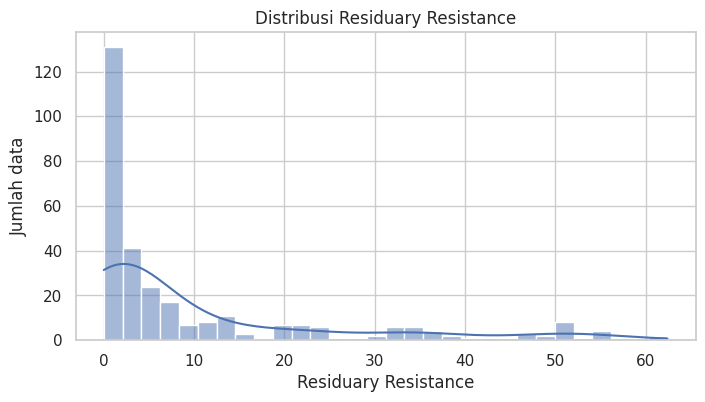

In [20]:
plt.figure(figsize=(8, 4))
sns.histplot(df_clean[TARGET_COL], bins=30, kde=True)
plt.title("Distribusi Residuary Resistance")
plt.xlabel("Residuary Resistance")
plt.ylabel("Jumlah data")
plt.show()

> Berdasarkan histogram, di rentang mana nilai target paling banyak muncul?

Jawaban: Nilai target paling banyak muncul pada rentang rendah, sekitar 0.010 sampai 2.090.

> Apakah distribusi target terlihat simetris atau cenderung miring?

Jawaban: Distribusi target cenderung miring ke kanan karena ada nilai resistance yang jauh lebih tinggi.

### Hitung korelasi fitur numerik dengan target

Hitung korelasi fitur numerik terhadap target `residuary_resistance`.

In [21]:
numeric_corr = df_clean.corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
numeric_corr

froude_number                0.810
longitudinal_position        0.019
length_beam_ratio           -0.001
length_displacement_ratio   -0.003
beam_draught_ratio          -0.012
prismatic_coefficient       -0.029
Name: residuary_resistance, dtype: float64

> Berdasarkan output korelasi, fitur apa yang memiliki korelasi positif paling tinggi terhadap target?

Jawaban: Fitur `froude_number` memiliki korelasi positif paling tinggi terhadap target.

> Apakah fitur lain memiliki korelasi yang mendekati `froude_number`?

Jawaban: Tidak. Korelasi fitur lain jauh lebih kecil dibandingkan `froude_number`.

### Buat bar plot korelasi numerik

Gunakan bar plot untuk melihat kekuatan korelasi fitur numerik dengan target.

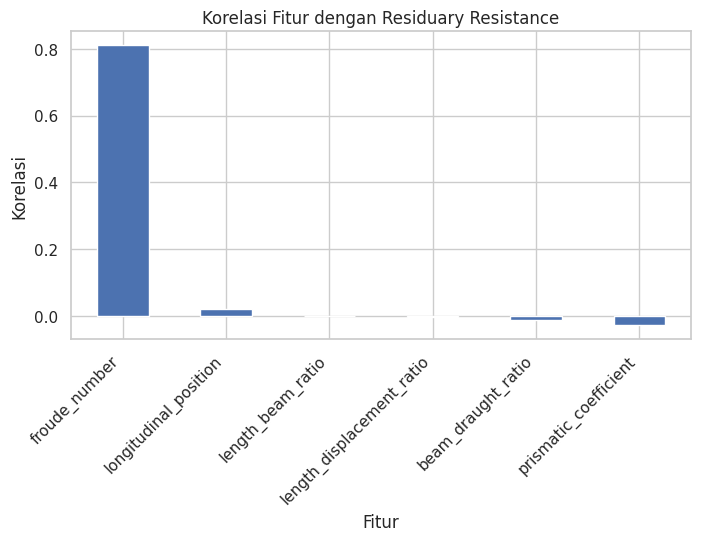

In [22]:
plt.figure(figsize=(8, 4))
numeric_corr.plot(kind="bar")
plt.title("Korelasi Fitur dengan Residuary Resistance")
plt.xlabel("Fitur")
plt.ylabel("Korelasi")
plt.xticks(rotation=45, ha="right")
plt.show()

> Berdasarkan bar plot, fitur mana yang paling menonjol hubungannya dengan target?

Jawaban: `froude_number` paling menonjol hubungannya dengan target.

### Buat line plot rata-rata target berdasarkan froude_number

Gunakan line plot untuk melihat rata-rata target pada setiap nilai `froude_number`.

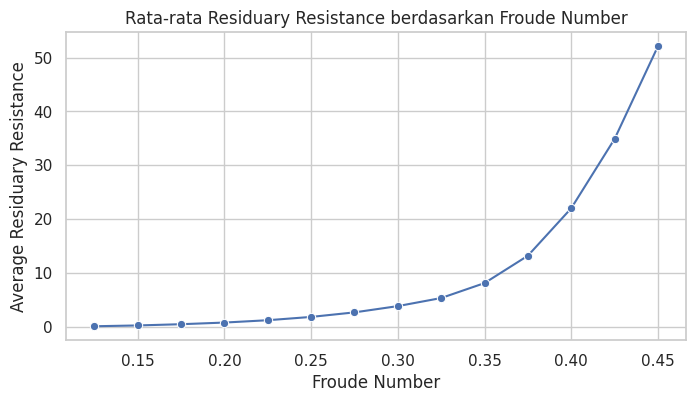

In [23]:
froude_mean = df_clean.groupby("froude_number")[TARGET_COL].mean().reset_index()

plt.figure(figsize=(8, 4))
sns.lineplot(data=froude_mean, x="froude_number", y=TARGET_COL, marker="o")
plt.title("Rata-rata Residuary Resistance berdasarkan Froude Number")
plt.xlabel("Froude Number")
plt.ylabel("Average Residuary Resistance")
plt.show()

> Berdasarkan line plot, bagaimana perubahan rata-rata target saat `froude_number` semakin besar?

Jawaban: Rata-rata target meningkat tajam saat `froude_number` semakin besar.

> Mengapa line plot lebih tepat daripada scatter plot untuk bagian ini?

Jawaban: Line plot lebih tepat karena `froude_number` memiliki nilai level berurutan, sehingga rata-rata per level lebih mudah dibaca.

### Buat boxplot target berdasarkan longitudinal_position

Gunakan boxplot untuk membandingkan persebaran target pada setiap nilai `longitudinal_position`.

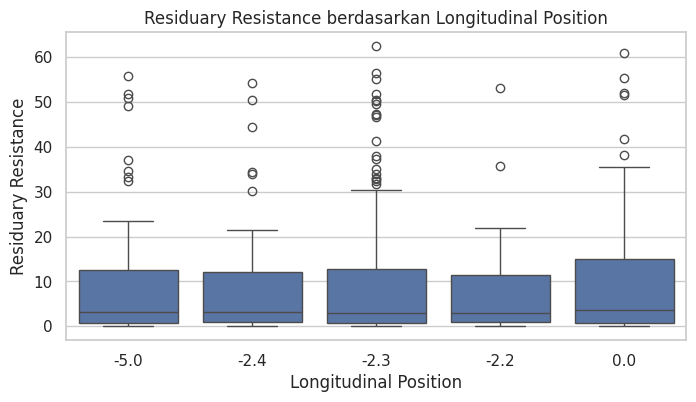

In [24]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_clean, x="longitudinal_position", y=TARGET_COL)
plt.title("Residuary Resistance berdasarkan Longitudinal Position")
plt.xlabel("Longitudinal Position")
plt.ylabel("Residuary Resistance")
plt.show()

> Berdasarkan boxplot, apakah perbedaan target antar nilai `longitudinal_position` terlihat sebesar pengaruh `froude_number`?

Jawaban: Tidak. Perbedaan antar nilai `longitudinal_position` tidak terlihat sebesar pola pada `froude_number`.

> Mengapa boxplot sesuai untuk fitur ini?

Jawaban: Boxplot sesuai karena `longitudinal_position` hanya memiliki beberapa nilai kelompok.

## 6 - Feature dan Target

### Pisahkan fitur awal

Pisahkan semua kolom selain target sebagai fitur awal.

In [25]:
X_raw_model = df_clean.drop(columns=[TARGET_COL])

### Pisahkan target

Simpan kolom target ke dalam variabel `y`.

In [26]:
y = df_clean[TARGET_COL]

### Gunakan fitur numerik

Gunakan fitur numerik yang sudah tersedia karena dataset ini tidak memiliki kolom kategori.

In [27]:
X = X_raw_model.copy()

### Tampilkan ukuran fitur

Tampilkan ukuran `X` yang akan digunakan untuk modeling.

In [28]:
X.shape

(308, 6)

> Berdasarkan output, berapa jumlah baris dan fitur pada `X`?

Jawaban: `X` memiliki 308 baris dan 6 fitur.

### Tampilkan ukuran target

Tampilkan ukuran `y` sebagai target model.

In [29]:
y.shape

(308,)

> Berdasarkan output, berapa jumlah nilai target pada `y`?

Jawaban: `y` memiliki 308 nilai target.

## 7 - Train-Test Split

### Tentukan parameter split

Tentukan `test_size` dan `random_state` yang akan digunakan.

In [30]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

> Berdasarkan nilai `test_size`, berapa persen data uji dan berapa persen data latih yang digunakan?

Jawaban: Data uji sebanyak 20% dan data latih sebanyak 80%.

### Bagi data train dan test

Bagi fitur dan target menjadi data train dan data test.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

### Tampilkan ukuran X_train

Tampilkan ukuran fitur pada data train.

In [32]:
X_train.shape

(246, 6)

### Tampilkan ukuran X_test

Tampilkan ukuran fitur pada data test.

In [33]:
X_test.shape

(62, 6)

> Berdasarkan output, berapa jumlah baris pada data train dan data test?

Jawaban: Data train memiliki 246 baris dan data test memiliki 62 baris.

## 8 - Feature Scaling

### Buat object scaler

Buat object `StandardScaler` untuk menyamakan skala fitur.

In [34]:
scaler = StandardScaler()

### Fit dan transform data train

Fit scaler pada data train, lalu ubah data train ke skala standar.

In [35]:
X_train_scaled = scaler.fit_transform(X_train)

### Transform data test

Ubah data test menggunakan scaler yang sudah di-fit pada data train.

In [36]:
X_test_scaled = scaler.transform(X_test)

## 9 - Linear Regression Model

### Buat model Linear Regression

Buat object model Linear Regression.

In [37]:
model = LinearRegression()

### Latih model

Latih model menggunakan data train yang sudah di-scale.

In [38]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


> Berdasarkan output, apa tanda bahwa model Linear Regression sudah berhasil dilatih dan siap digunakan?

Jawaban: Output menampilkan object `LinearRegression()`, yang berarti model berhasil dibuat dan dilatih.

### Tampilkan intercept model

Tampilkan nilai intercept dari model Linear Regression.

In [39]:
model.intercept_

np.float64(11.363780487804881)

> Berdasarkan output, berapa nilai intercept model?

Jawaban: Nilai intercept model sekitar 11.364.

### Tampilkan koefisien model

Tampilkan koefisien setiap fitur dalam bentuk tabel.

In [40]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

coef_table

,Feature,Coefficient
5,froude_number,12.775
0,longitudinal_position,0.608
2,length_displacement_ratio,-0.046
4,length_beam_ratio,-0.071
3,beam_draught_ratio,-0.104
1,prismatic_coefficient,-0.247


> Berdasarkan tabel koefisien, fitur mana yang memiliki koefisien positif terbesar?

Jawaban: Fitur `froude_number` memiliki koefisien positif terbesar.

> Fitur mana yang memiliki koefisien negatif terbesar arahnya?

Jawaban: Fitur `prismatic_coefficient` memiliki koefisien negatif terbesar arahnya.

## 10 - Prediksi dan Evaluasi

### Buat prediksi data train

Gunakan model untuk membuat prediksi pada data train.

In [41]:
y_train_pred = model.predict(X_train_scaled)

### Buat prediksi data test

Gunakan model untuk membuat prediksi pada data test.

In [42]:
y_test_pred = model.predict(X_test_scaled)

### Tampilkan lima prediksi pertama

Bandingkan lima nilai aktual dan prediksi pertama pada data test.

In [43]:
prediction_preview = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
}).head()

prediction_preview

,Actual,Predicted
0,6.310,14.755
1,7.160,18.447
2,0.350,-6.750
3,1.370,2.736
4,21.090,24.801


> Berdasarkan lima prediksi pertama, prediksi mana yang terlihat paling dekat dengan nilai aktual?

Jawaban: Baris keempat terlihat paling dekat karena actual 1.370 dan predicted sekitar 2.736.

> Prediksi mana yang terlihat paling jauh dari nilai aktual?

Jawaban: Baris pertama terlihat paling jauh karena actual 6.310 dan predicted sekitar 14.755.

### Hitung MAE train

Hitung MAE pada data train.

In [44]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_train

7.420320853338283

### Hitung MAE test

Hitung MAE pada data test.

In [45]:
mae_test = mean_absolute_error(y_test, y_test_pred)
mae_test

6.807526813027249

> Berdasarkan output, berapa nilai MAE test?

Jawaban: Nilai MAE test sekitar 6.808.

### Hitung RMSE train

Hitung RMSE pada data train.

In [46]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_train

np.float64(9.036930232589663)

### Hitung RMSE test

Hitung RMSE pada data test.

In [47]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
rmse_test

np.float64(8.2220821680711)

> Berdasarkan output, berapa nilai RMSE test?

Jawaban: Nilai RMSE test sekitar 8.222.

### Hitung R2 train

Hitung R2 Score pada data train.

In [48]:
r2_train = r2_score(y_train, y_train_pred)
r2_train

0.6675349731715722

### Hitung R2 test

Hitung R2 Score pada data test.

In [49]:
r2_test = r2_score(y_test, y_test_pred)
r2_test

0.5450299966509164

> Berdasarkan output, berapa nilai R2 test?

Jawaban: Nilai R2 test sekitar 0.545.

### Buat tabel evaluasi akhir

Gabungkan MAE, RMSE, dan R2 Score untuk data train dan data test.

In [50]:
evaluation_table = pd.DataFrame({
    "Data": ["Train", "Test"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R2 Score": [r2_train, r2_test]
})

evaluation_table

,Data,MAE,RMSE,R2 Score
0,Train,7.420,9.037,0.668
1,Test,6.808,8.222,0.545


> Berdasarkan tabel evaluasi, bagaimana perbandingan MAE train dan MAE test?

Jawaban: MAE test sekitar 8.26% lebih rendah daripada MAE train.

> Berdasarkan tabel evaluasi, bagaimana perbandingan RMSE train dan RMSE test?

Jawaban: RMSE test sekitar 9.02% lebih rendah daripada RMSE train.

> Berdasarkan tabel evaluasi, bagaimana perbandingan R2 train dan R2 test?

Jawaban: R2 test sekitar 18.35% lebih rendah daripada R2 train.

### Visualisasikan aktual vs prediksi

Gunakan scatter plot untuk membandingkan nilai aktual dan prediksi pada data test.

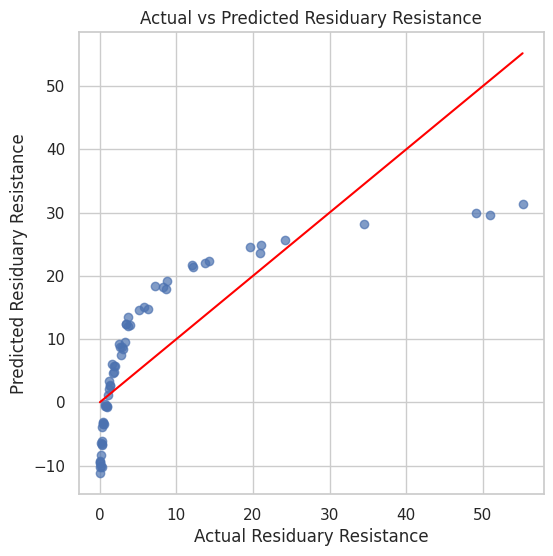

In [51]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.title("Actual vs Predicted Residuary Resistance")
plt.xlabel("Actual Residuary Resistance")
plt.ylabel("Predicted Residuary Resistance")
plt.show()

## 11 - Kesimpulan

Dataset Yacht Hydrodynamics digunakan untuk memprediksi `residuary_resistance` berdasarkan fitur desain dan kondisi hidrodinamika kapal. Dataset memiliki 308 baris dan 7 kolom. Data tidak memiliki missing value dan memiliki 0 baris duplikat penuh.

EDA menunjukkan bahwa target `residuary_resistance` cenderung miring ke kanan. Fitur yang paling kuat hubungannya dengan target adalah `froude_number`, dan rata-rata target meningkat saat `froude_number` semakin besar. Semua fitur sudah numerik, sehingga encoding kategori tidak diperlukan.

Data dibagi menjadi 80% data train dan 20% data test. Berdasarkan evaluasi, MAE test bernilai sekitar 6.808, RMSE test sekitar 8.222, dan R2 test sekitar 0.545.